## Implementing InfoMap using the Louvain algorithm

The primary limitation of the InfoMap approach lies in the computational challenge of identifying the optimal partition $B$ that minimizes the Map Equation functional. The energy landscape of the system is inherently non-convex, and characterizing all local minima of the function $L(B)$ is an NP-hard problem. 

A brute-force search is computationally intractable, as the number of possible partitions for a graph with $N$ nodes is given by the Bell number $B(N)$, which scales asymptotically as:

$$
B(N) \approx e^{e^N - 1}
$$

In 2008, [Blondel et al.](https://arxiv.org/abs/0803.0476) proposed a "greedy" heuristic, known as the Louvain method, designed to efficiently identify a high-quality partition that minimizes the objective function. Originally implemented to maximise the Newmann modularity function $Q$, it can be quite easily adapted to minimize a generic functional defined on the graph

### How does it work?

The method is composed of two distinct phases, repeated until the system reaches convergence. Call $L$ the objective function.

1.  **Local optimization (greedy phase):** Initially, each node is assigned to a unique community. The algorithm sequentially visits the nodes and evaluates, for each node $i$, the change in the function $L$ resulting from moving $i$ into the community of one of its neighbors. The node is transferred to the community that yields the maximum reduction in $L$. This relaxation process is iterated over all nodes until a stable local minimum is reached, where no further single move produces an energy gain. We have reached a local minimum

2.  **Global aggregation:** Once the partition stabilizes, a new graph is constructed in which the communities identified in the previous phase are collapsed into single "super-nodes". Links internal to the original communities are transformed into weighted *self-loops* on the super-node, while connections between nodes of different communities are aggregated to form weighted edges between the new super-nodes.


The reduced graph serves as the input for the subsequent iteration of the first phase. The combination of these two phases is called *pass*: the algorithm terminates when passes no longer yield significant improvements in $L$, revealing the optimal hierarchical structure of the network.

A small remark on the hierarchical structure of the algorithm: while the Louvain procedure is inherently capable of producing a multi-level description of the network (detecting communities within communities), the scope of this work is strictly limited to the final partition. Consequently, the super-nodes remaining at the algorithm's convergence define the set of identified communities.


![](./fig/Louvain.png)

In [1]:
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time

import networkx as nx
from infomap import Infomap

Consider the famous Zachary's karate club network. We will use this simple network to carry out the first analyses in a pictorial way

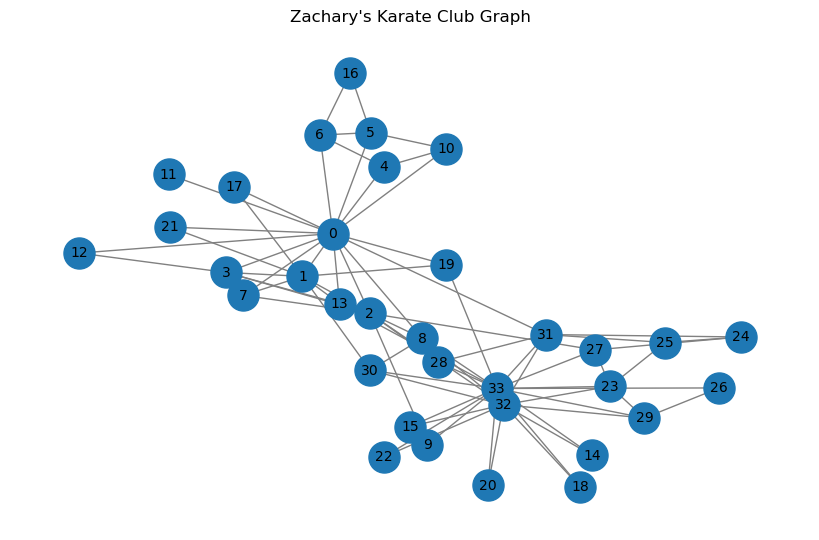

In [2]:
G = nx.karate_club_graph()

plt.figure(figsize=(8, 5))
nx.draw(G, nx.spring_layout(G, seed=42), with_labels=True, node_size=500, edge_color="gray", font_size=10, font_color="black")
plt.title("Zachary's Karate Club Graph")
plt.show()

Given a partition $M$, the final formula for the map equation $L(M)$ reads:

$$
L(M) = \left(\sum_i^m q_{i\curvearrowright}\right) \log\left(\sum_i^m q_{i\curvearrowright}\right)  - 2 \sum_i^m q_{i\curvearrowright} \log(q_{i\curvearrowright}) + \sum_i^m \left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) \log\left(q_{i\curvearrowright} + \sum_{\alpha \in i} p_\alpha\right) + H[p_\alpha]
$$
where $q_{i\curvearrowright}$ is the probability that in a generic timestep the random walker will leave the module $i$ and $p_\alpha$ is the equilibrium distribution value of the residence probability for the walker.


Let us first define a set of useful utility functions:

In [7]:
# This computes the shannon Entropy for a distribution
def shannonEntropy(probabilities):
    h = 0
    for p in probabilities:
        if p > 0:
            h -= p * math.log2(p)
    return h

# This function computes the map equation for a given partition of the graph, using the equilibrium probabilities of the nodes and a teleportation parameter tau.
def mapEquation(G, partition, equilibriumProbabilities, tau=0.15):
    # Dict containing the modules
    modules = set(partition.values())
    n = G.number_of_nodes()
    q_out = {m: 0.0 for m in modules}  # q_i for each module
    p_sum = {m: 0.0 for m in modules}  # \sum_\alpha \in i p_\alpha for each i
    mod_nodes = {m: [] for m in modules} # List of nodes in each module

    # Let's populate these dicts traversing the network
    for u in G.nodes():
        # Module of node u
        m_u = partition[u]
        # Its equilibrium probability p_u
        pr_u = equilibriumProbabilities[u]
        # Update the sum of probabilities for the module m_u
        p_sum[m_u] += pr_u
        mod_nodes[m_u].append(u)
        # Now iterate over all the neighbors ...
        deg_u = G.degree(u, weight='weight')
        if deg_u > 0:
            # But only if the neighbors are in differern modules!
            for v in G.neighbors(u):
                m_v = partition[v]
                if m_u != m_v: 
                    # Get the weight of the edge (u, v), if one is there, otherwise default to 1
                    w_uv = G[u][v].get('weight', 1.0)
                    # Using the formula in the paper. This is the contribution to the flow exiting module m_u due to the edge (u, v)
                    q_out[m_u] += (1-tau)*(pr_u / deg_u) * w_uv 
    # Now we need to add the contribution of teleportation (which is global)
    for m in modules:
        n_i = len(mod_nodes[m]) 
        teleport_flow = tau * (n - n_i) / (n - 1) * p_sum[m]
        q_out[m] += teleport_flow

    # Now let's compute the first term for the map equation
    total_q = sum(q_out.values())
    if total_q < 1e-12:   # regularization to avoid log(0), 0 log(0) = 0
        L_1 = 0.0
    else:
        Q_probs = [val / total_q for val in q_out.values()]
        L_1 = total_q * shannonEntropy(Q_probs)

    # Computing the second term for the map equation
    L_2 = 0.0
    for m in modules:
        p_circle = p_sum[m] + q_out[m]
        
        if p_circle > 1e-12:
            probs_internal = [equilibriumProbabilities[u] / p_circle for u in mod_nodes[m]]
            probs_internal.append(q_out[m] / p_circle)
            L_2 += p_circle * shannonEntropy(probs_internal)
            
    return L_1 + L_2

Let's try and see whether it works on some trivial examples. First of all, let us use the 1-module case:

In [4]:
# A trivial partition: all nodes in the same module
# The map equation for this partition should be equal to the entropy of the equilibrium probabilities
partition = {u: 0 for u in G.nodes()}
# To compute the probability distribution, we use PageRank with tau = 0.15 as suggested in the original paper
equilibriumProbabilities = np.array([nx.pagerank(G, alpha = .85)[u] for u in G.nodes()])
# To test whether this is correct, we can compute
# equilibriumProbabilities = np.array([nx.pagerank(G, alpha = 1, weight=None)[u] for u in G.nodes()])
# and compare this against
# equilibriumProbabilities = np.array([nx.degree(G, u) / (2 * G.number_of_edges()) for u in G.nodes()])
L = mapEquation(G, partition, equilibriumProbabilities)

print(f"Map equation for trivial partition: {L:.4f}")
print(f"Entropy for the equilibrium probabilities: {shannonEntropy(equilibriumProbabilities):.4f}")
print(f"This means that we need approximately {L:.2f} bits to describe the trajectory of a random walker on the graph, if we use the trivial partition")
print(f"Note this is still smaller than the raw bit content of the graph, which is {np.log2(len(G.nodes())):.2f} bits")

Map equation for trivial partition: 4.7396
Entropy for the equilibrium probabilities: 4.7396
This means that we need approximately 4.74 bits to describe the trajectory of a random walker on the graph, if we use the trivial partition
Note this is still smaller than the raw bit content of the graph, which is 5.09 bits


Historically, the network has a natural separation into two factions, effectively providing a ground truth. We calculate the $L$ value for this specific partition to serve as a baseline.

Map equation for partition with two "correct" modules: 4.5885


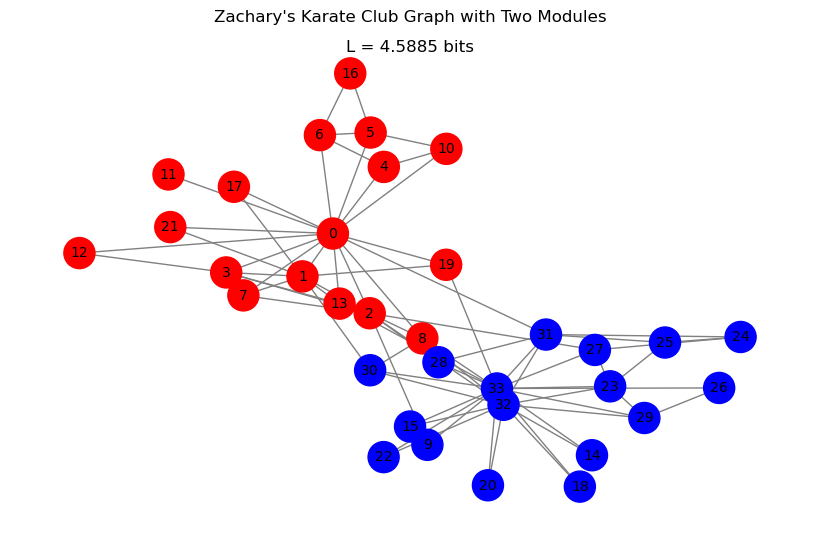

In [5]:
# Now imagine we divide the graph into two modules
# We can use the partition given by the original network, which is the following:
partition = {u : 0 if u in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 16, 17, 19, 21] else 1 for u in G.nodes()}
L = mapEquation(G, partition, equilibriumProbabilities)
print(f"Map equation for partition with two \"correct\" modules: {L:.4f}")

#Draw the graph with the partition
color_map = ['red' if partition[u] == 0 else 'blue' for u in G.nodes()]
plt.figure(figsize=(8, 5))
nx.draw(G, nx.spring_layout(G, seed=42), with_labels=True, node_size=500, edge_color="gray", font_size=10, font_color="black", node_color=color_map)
plt.title("Zachary's Karate Club Graph with Two Modules")
plt.suptitle(fr"L = {L:.4f} bits")
plt.show()

This is indeed smaller than the trivial partition analyzed above

---

Now all that is left to do is implement the InfoMap algorithm

In [5]:
# This function implements the first phase of the Louvain algorithm
def findCommunities(G, nodes_pr, max_loops=20):
    # Initialize each node in its own module
    current_partition = {u: u for u in G.nodes()}
    # Calculate initial L
    current_L = mapEquation(G, current_partition, nodes_pr)
    
    loop = 0
    improvement = True      # a flag, verify whether we have improved
    while improvement and loop < max_loops:
        improvement = False
        loop += 1
        
        nodes_list = list(G.nodes())
        # This is important. In the seminal paper, the authors claim that it would be better to visit the nodes in random order
        # to avoid a systematic bias
        random.shuffle(nodes_list)   
        
        moves_count = 0
        
        for u in nodes_list:
            best_mod = current_partition[u]   # Set the best module to the curren ont
            best_L_local = current_L          
            original_mod = current_partition[u]
            
            # Find the modules of the neighbors of u
            neighbor_modules = set()
            for v in G.neighbors(u):
                neighbor_modules.add(current_partition[v])
            neighbor_modules.discard(original_mod)
            
            # Now let's try and move u to each of the neighbor modules, and see if we improve the map equation
            for mod in neighbor_modules:
                temp_partition = current_partition.copy() 
                temp_partition[u] = mod                     # Create a temporary partition where we move u to the new module
                # Computes L for the new partition
                new_L = mapEquation(G, temp_partition, nodes_pr)
                if new_L < best_L_local:
                    best_L_local = new_L
                    best_mod = mod
            #If we found a better module, let's move u there and update the current L
            if best_mod != original_mod:
                current_partition[u] = best_mod
                current_L = best_L_local
                improvement = True
                moves_count += 1

    return current_partition, current_L

# Main function that implements the full info-map Louvain algorithm
def infoMapLouvain(G, max_loops=200, tau = 0.15):
    # Create the equilibrium distribution (PageRank) for the original graph. This is constant, so let's cache it
    equilibriumProbabilities = nx.pagerank(G, alpha=1-tau)
    # Initially, each node is in its own module
    final_partition = {u: u for u in G.nodes()}

    G_copy = G.copy()
    current_pr = equilibriumProbabilities
    
    finish = False
    level = 0
    while not finish:
        level += 1
        # Use the previous function to find the best partition at this level
        current_partition, current_L = findCommunities(G_copy, current_pr, max_loops)
        # Now we have to create a new super-graph where each community is a super-node, and the weights are the aggregated flows
        unique_modules = set(current_partition.values())

        if len(unique_modules) == 1:                         # We have arrived to a single cluster, end the algorithm
            finish = True
            break
        if len(unique_modules) == G_copy.number_of_nodes():  # We haven't improved anything, end the algorithm
            finish = True
            break

        # Update the final partition to reflect the new module assignments
        new_final_partition = {}
        for original_node, current_module in final_partition.items():
            new_final_partition[original_node] = current_partition[current_module]
        final_partition = new_final_partition

        # Create the super-graph
        new_G = nx.Graph()
        new_G.add_nodes_from(unique_modules)
        
        new_pr = {m: 0.0 for m in unique_modules}
        for node, module in current_partition.items():
            new_pr[module] += current_pr[node]
            
        for u, v in G_copy.edges():
            m_u = current_partition[u]
            m_v = current_partition[v]
            
            weight = G_copy[u][v].get('weight', 1.0)
            
            if new_G.has_edge(m_u, m_v):
                new_G[m_u][m_v]['weight'] += weight
            else:
                new_G.add_edge(m_u, m_v, weight=weight)
        
        G_copy = new_G
        current_pr = new_pr

    return final_partition


# Helper function to draw the graph with a partition
def draw_partition(G, partition_dict, title):
    pos = nx.spring_layout(G, seed=42)
    node_colors = [partition_dict[n] for n in G.nodes()]
    plt.figure(figsize=(10, 7))
    plt.title(title)
    nx.draw(G, pos, with_labels=True, node_color=node_colors, cmap=plt.cm.tab10, node_size=500, edge_color="gray", font_color="black")
    plt.show()

Let's try and use it on the Zachary's network

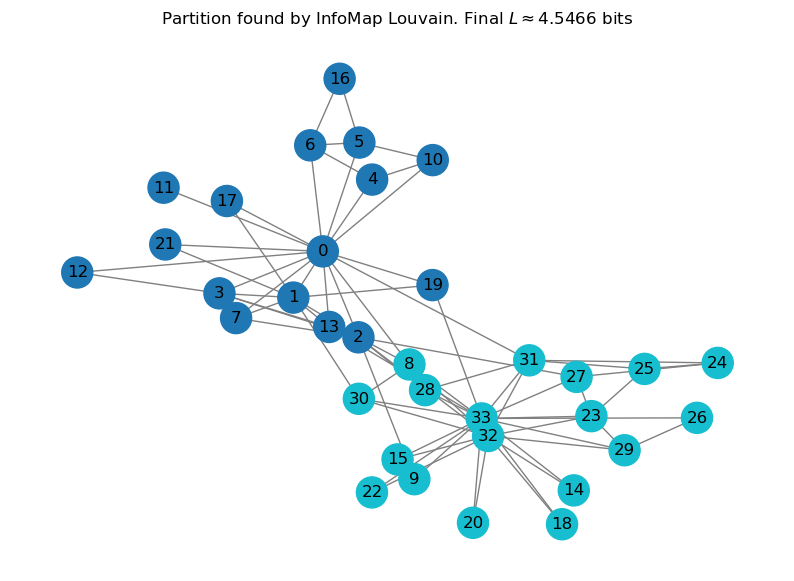

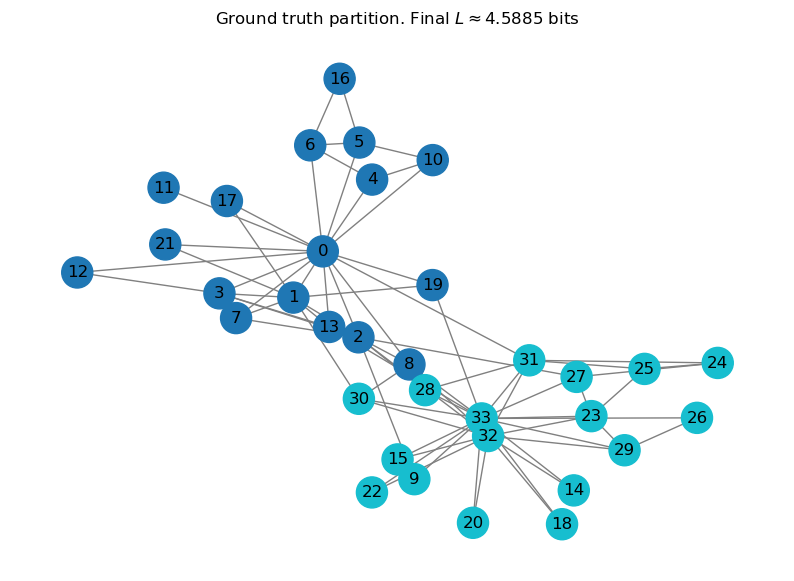

In [7]:
G = nx.karate_club_graph()
final_partition = infoMapLouvain(G)
L = mapEquation(G, final_partition, nx.pagerank(G, alpha=0.85))
draw_partition(G, final_partition, title=fr"Partition found by InfoMap Louvain. Final $L \approx {L:.4f}$ bits")

ground_truth = {}
for n in G.nodes(data=True):
    ground_truth[n[0]] = 0 if n[1]['club'] == 'Mr. Hi' else 1
L_gt = mapEquation(G, ground_truth, nx.pagerank(G, alpha=0.85))
draw_partition(G, ground_truth, title=fr"Ground truth partition. Final $L \approx {L_gt:.4f}$ bits")

Notably, the description length $L$ associated with the original ground truth is higher than the value minimized by our algorithm. This confirms that the partition found via map equation represents a statistically stronger modular structure compared to the historically observed split

### Now using the official InfoMap implementation

We now employ the official implementation of the InfoMap algorithm, available at https://www.mapequation.org/. This C++ based library represents the state-of-the-art in flow-based community detection and is highly optimized both in terms of computational speed and stochastic search accuracy. Unlike simple greedy heuristics, it employs advanced optimization techniques to effectively explore the solution space and avoid local minima.

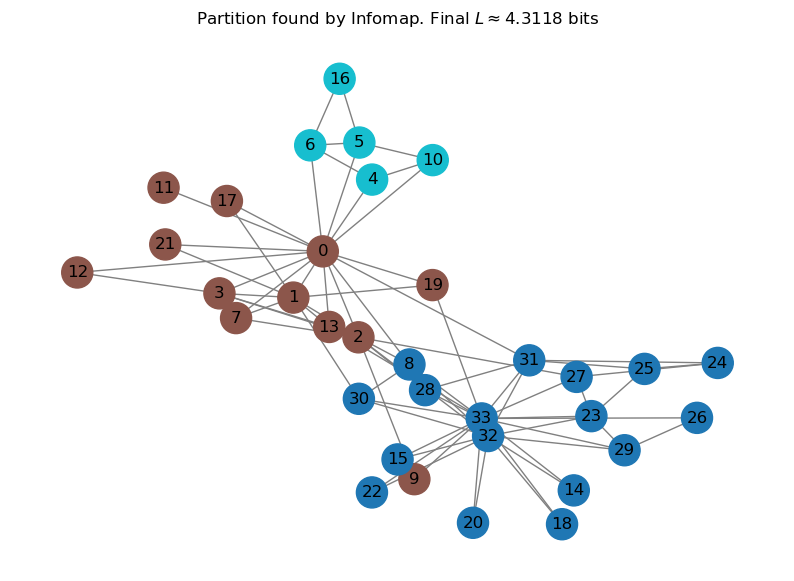

In [10]:
# The usual graph
G = nx.karate_club_graph()

im = Infomap("--silent --two-level") 
im.add_links(G.edges())
im.run()

partition_infomap = {}
for node in im.nodes:
    partition_infomap[node.node_id] = node.module_id

draw_partition(G, partition_infomap, title=fr"Partition found by Infomap. Final $L \approx {im.codelength:.4f}$ bits")

Notably, the official implementation revealed a 3-community structure with a description length L substantially lower than that found by our Louvain-based approach. While our heuristic settled for the socially intuitive split (2 factions), the optimized algorithm minimized the information flow further by isolating a third, highly interconnected subgroup.

## Some other networks:

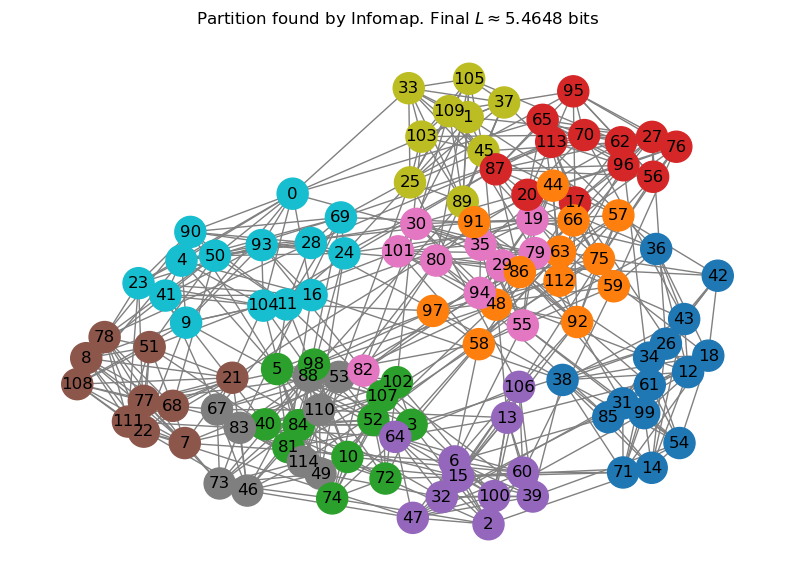

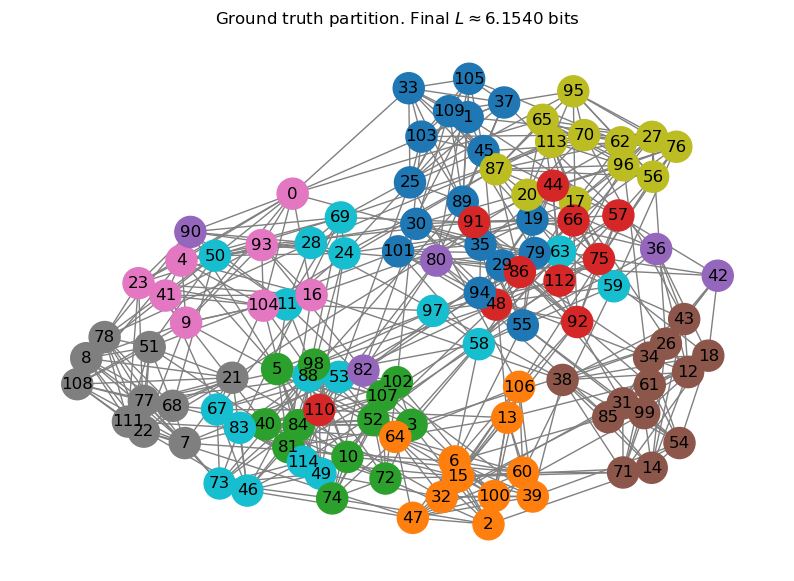

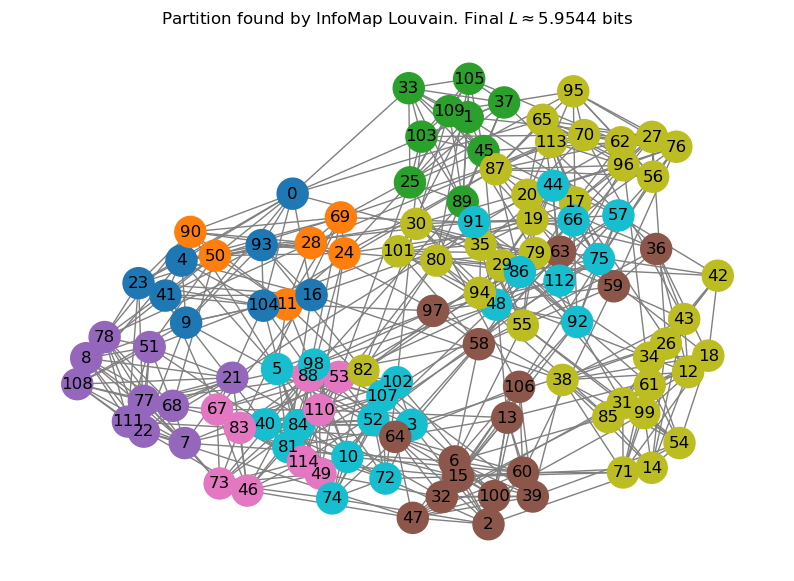

In [12]:
G = nx.read_gml("./network/football.gml")
G = nx.convert_node_labels_to_integers(G)
im = Infomap("--silent --two-level") 
im.add_links(G.edges())
im.run()

partition_infomap = {}
for node in im.nodes:
    partition_infomap[node.node_id] = node.module_id

draw_partition(G, partition_infomap, title=fr"Partition found by Infomap. Final $L \approx {im.codelength:.4f}$ bits")
ground_truth = {n: G.nodes[n]['value'] for n in G.nodes()}
L_gt = mapEquation(G, ground_truth, nx.pagerank(G, alpha=0.85))
draw_partition(G, ground_truth, title=fr"Ground truth partition. Final $L \approx {L_gt:.4f}$ bits")

partition_louvain = infoMapLouvain(G)
L_louvain = mapEquation(G, partition_louvain, nx.pagerank(G, alpha=0.85))
draw_partition(G, partition_louvain, title=fr"Partition found by InfoMap Louvain. Final $L \approx {L_louvain:.4f}$ bits")

How can we compare the partitions found by Infomap and InfoMap Louvain against the ground truth? We can use metrics like NMI to quantify the similarity between the partitions. The NMI is defined as:

$$
\text{NMI}(X, Y) = \frac{2 \cdot I(X: Y)}{H(X) + H(Y)}
$$

Where:
* $X$ and $Y$ represent the two partitions being compared (e.g., ground truth vs. algorithm).
* $I(X: Y)$ is the mutual information between the partitions. It is not normalized however
* $H(X)$ and $H(Y)$ are the entropies of the partitions, representing the uncertainty associated with each clustering:
    $$H(X) = - \sum_{x \in X} p(x) \log p(x)$$


The NMI value ranges from **0 to 1**:
* **$\text{NMI} = 1$**: The two partitions are identical (perfect correlation). This means $H(X) = H(Y)$ and $I(X:Y) = H(X)$
* **$\text{NMI} \approx 0$**: The two partitions are independent (no correlation, hence $I(X:Y)=0$). 

This metric is particularly suitable for community detection because it is invariant to the permutation of cluster labels. It effectively measures the shared information regardless of whether the algorithm labels a group as "1" and the ground truth labels it as "A". Quoting from the paper of [Newman et Al](https://www.nature.com/articles/s41467-025-66150-8).: *Mutual information works by asking how efficiently we can describe one labeling if we already know the other. Specifically, it measures how much less information it takes to communicate the first labeling if we know the second versus if we do not. As an example, mutual information is commonly used in network science to evaluate the performance of algorithms for network community detection*

N.B. the paper above claims that NMI is somewhat biased. For the sake of simplicity, we are going to assume NMI is valid

In [13]:
from sklearn.metrics import normalized_mutual_info_score

nodes_sorted = sorted(G.nodes())

list_ground_truth = [ground_truth[n] for n in nodes_sorted]
list_infomap      = [partition_infomap[n] for n in nodes_sorted]
list_louvain     = [partition_louvain[n] for n in nodes_sorted]

nmi = normalized_mutual_info_score(list_ground_truth, list_infomap)
nmi_louvain = normalized_mutual_info_score(list_ground_truth, list_louvain)
nmi_louvain_opt = normalized_mutual_info_score(list_infomap, list_louvain)

print(f"NMI (ground truth -- optimized InfoMap): {nmi:.4f}")
print(f"NMI (ground truth -- Louvain): {nmi_louvain:.4f}")
print(f"NMI (InfoMap -- Louvain): {nmi_louvain_opt:.4f}")

NMI (ground truth -- optimized InfoMap): 0.9114
NMI (ground truth -- Louvain): 0.9242
NMI (InfoMap -- Louvain): 0.9744


Now onto a different network. This one has $\approx 2700$ nodes

In [3]:
edges_df = pd.read_csv('network/cora.edges', sep=',', header=None, names=['source', 'target', 'weight'])
G = nx.from_pandas_edgelist(edges_df, 'source', 'target')

labels_df = pd.read_csv('network/cora.node_labels', sep=',', header=None, names=['node_id', 'label'])
ground_truth = dict(zip(labels_df['node_id'], labels_df['label']))
print(f"Ground truth classes: {set(ground_truth.values())}")

print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Ground truth classes: {1, 2, 3, 4, 5, 6, 7}
Nodes: 2708 | Edges: 5278


In [ ]:
L_gt = mapEquation(G, ground_truth, nx.pagerank(G, alpha=0.85))

im = Infomap("--silent --directed --two-level") 
im.add_links(G.edges())
start = time.time()
im.run()
end = time.time()
print(f"Infomap execution time: {end - start:.2f} seconds")
partition_infomap = {}
for node in im.nodes:
    partition_infomap[node.node_id] = node.module_id
L_im = mapEquation(G, partition_infomap, nx.pagerank(G, alpha=0.85))


start = time.time()
partition_louvain = infoMapLouvain(G)
end = time.time()
print(f"InfoMap Louvain execution time: {end - start:.2f} seconds")
L_louvain = mapEquation(G, partition_louvain, nx.pagerank(G, alpha=0.85))

nodes_sorted = sorted(G.nodes())
list_ground_truth = [ground_truth[n] for n in nodes_sorted]
list_infomap      = [partition_infomap[n] for n in nodes_sorted]
list_louvain     = [partition_louvain[n] for n in nodes_sorted]

nmi = normalized_mutual_info_score(list_ground_truth, list_infomap)
nmi_louvain = normalized_mutual_info_score(list_ground_truth, list_louvain)
nmi_louvain_opt = normalized_mutual_info_score(list_infomap, list_louvain)

print(f"NMI (ground truth -- optimized InfoMap): {nmi:.4f}")
print(f"NMI (ground truth -- Louvain): {nmi_louvain:.4f}")
print(f"NMI (InfoMap -- Louvain): {nmi_louvain_opt:.4f}")
print(f"Map equation for optimized InfoMap partition: {L_im:.4f} bits")
print(f"Map equation for ground truth partition: {L_gt:.4f} bits")
print(f"Map equation for Louvain partition: {L_louvain:.4f} bits")

print(f"Number of communities (Infomap): {len(set(list_infomap))}")
print(f"Number of communities (Louvain): {len(set(list_louvain))}")
print(f"Number of communities (Ground Truth): {len(set(list_ground_truth))}")

Infomap execution time: 0.04 seconds


In [9]:
im = Infomap("--silent --directed --two-level") 
im.add_links(G.edges())
start = time.time()
im.run()
end = time.time()

print(f"Infomap execution time: {end - start:.2f} seconds")
partition_infomap = {}
for node in im.nodes:
    partition_infomap[node.node_id] = node.module_id   
print(f"Map equation for optimized InfoMap partition: {mapEquation(G, partition_infomap, nx.pagerank(G, alpha=0.85)):.4f} bits")
print(f"Number of communities (Infomap): {len(set(partition_infomap.values()))}")

Infomap execution time: 0.05 seconds
Map equation for optimized InfoMap partition: 7.4535 bits
Number of communities (Infomap): 364
